In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
import nltk

In [16]:
df=pd.read_csv(r'D:\ProjectExhibition1\ProjectExb\Corona.csv')

In [17]:

import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import nltk

# Initialize lemmatizer
lemmatizer = WordNetLemmatizer()

# Define a function to clean text
def clean_text(text):
    try:
        # Remove URLs
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        # Remove mentions and hashtags
        text = re.sub(r'@\w+|#\w+', '', text)
        # Remove special characters and numbers
        text = re.sub(r'[^A-Za-z\s]', '', text)
        # Lowercase the text
        text = text.lower()
        # Tokenize the text
        tokens = word_tokenize(text)
        # Remove stop words
        tokens = [word for word in tokens if word not in stopwords.words('english')]
        # Lemmatize the tokens
        tokens = [lemmatizer.lemmatize(word) for word in tokens]
        # Join the tokens back into a single string
        cleaned_text = ' '.join(tokens)
        return cleaned_text
    except Exception as e:
        print(f"Error processing text: {text}\n{e}")
        return ''


# Apply the cleaning function to the 'text' column
df['cleaned_text'] = df['text'].apply(clean_text)

# Display the cleaned DataFrame
print(df[['text', 'cleaned_text']].head())


                                                text  \
0  @YuhuaWang5 If any one want to study how both ...   
1  @narendramodi @PMOIndia  - Are there any chanc...   
2  @Out5p0ken @racc1964 @WhiteHouse @realDonaldTr...   
3  why is there no bread left in any supermarket?...   
4  @MudiwaHood is this a joke or you mean it?Mayb...   

                                        cleaned_text  
0  one want study communist propaganda china viru...  
1  chance create covid relief fund india many hap...  
2  fairness probably cant pronounce corona virus ...  
3   bread left supermarket lot eat bread corona came  
4  joke mean itmaybe start asking mothercousins a...  


In [18]:
from nltk.sentiment import SentimentIntensityAnalyzer
# from tqdm.notebook import tqdm
from tqdm.auto import tqdm

sia=SentimentIntensityAnalyzer()

In [19]:
res={}
for i, row in tqdm(df.iterrows(), total=len(df)):
    text = row['cleaned_text']
    myid = row['id']
    res[myid]= sia.polarity_scores(text)
    

  0%|          | 0/34100 [00:00<?, ?it/s]

In [20]:
vaders=pd.DataFrame(res).T
vaders=vaders.reset_index().rename(columns={'index':'id'})
vaders=vaders.merge(df,how='left')
vaders.head()

,id,neg,neu,pos,compound,text,cleaned_text
0,1,0.163,0.732,0.106,-0.1779,@YuhuaWang5 If any one want to study how both ...,one want study communist propaganda china viru...
1,2,0.000,0.316,0.684,0.8689,@narendramodi @PMOIndia - Are there any chanc...,chance create covid relief fund india many hap...
2,3,0.000,1.000,0.000,0.0000,@Out5p0ken @racc1964 @WhiteHouse @realDonaldTr...,fairness probably cant pronounce corona virus ...
3,4,0.000,1.000,0.000,0.0000,why is there no bread left in any supermarket?...,bread left supermarket lot eat bread corona came
4,5,0.000,0.784,0.216,0.2960,@MudiwaHood is this a joke or you mean it?Mayb...,joke mean itmaybe start asking mothercousins a...


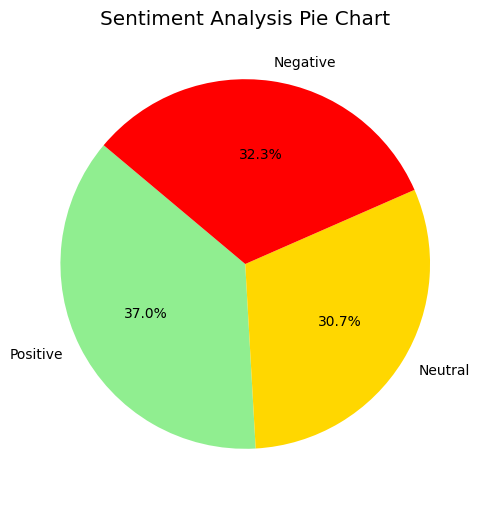

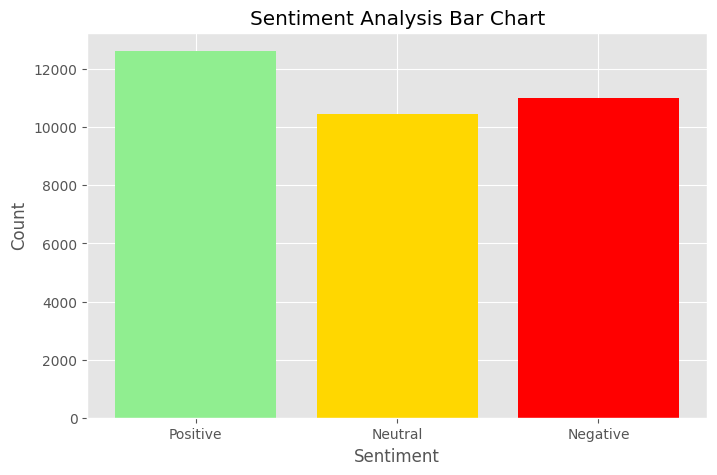

In [21]:
conditions = {
    'Positive': (vaders['compound'] > 0),
    'Neutral': (vaders['compound'] == 0),
    'Negative': (vaders['compound'] < 0)
}

sentiment_counts = {key: sum(value) for key, value in conditions.items()}

# Pie Chart
plt.figure(figsize=(6, 6))
plt.pie(
    sentiment_counts.values(),
    labels=sentiment_counts.keys(),
    autopct='%1.1f%%',
    colors=['lightgreen', 'gold', 'red'],
    startangle=140
)
plt.title('Sentiment Analysis Pie Chart')
plt.show()

# Bar Chart
plt.figure(figsize=(8, 5))
plt.bar(sentiment_counts.keys(), sentiment_counts.values(), color=['lightgreen', 'gold', 'red'])
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Analysis Bar Chart')
plt.show()